In [1]:
# ------- [Import all relevant libraries] -------

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Usual Suspects
import numpy as np           # Mathematical operations
import pandas as pd          # Data manipulation

# Visualization
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')
import seaborn as sns

# String manipulation
import re

# Mathematical Operations
import math

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# ML
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, 
    StratifiedKFold, cross_val_score
)

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# ML Model Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, make_scorer, f1_score, 
    ConfusionMatrixDisplay, confusion_matrix, roc_curve, auc, 
    roc_auc_score, classification_report,
)

import optuna

# Handle class imbalance
from imblearn.over_sampling import SMOTE

# Display settings
pd.set_option('display.max_colwidth', None)
from IPython.display import display

# MODELING

We will develop predictive models for H1N1 Vaccine Uptake and Seasonal Flu Vaccine Uptake independently.  
To ensure methodological rigor, the modeling workflow will proceed in three structured phases:

1. Baseline Modeling (Vanilla Iteration): We begin by training all selected classifiers using their default hyperparameters. This establishes foundational performance benchmarks, providing a reference point for evaluating subsequent enhancements.
2. Addressing Class Imbalance: Univariate exploration in the EDA phase revealed a significant imbalance in the target variable distributions. To mitigate this, techniques such as **class weighting** and **SMOTE oversampling** will be applied. Models will then be retrained to assess improvements in sensitivity to the minority class.
3. Hyperparameter Optimization: Once the strongest initial performers are identified, we will conduct targeted hyperparameter tuning to maximize predictive power, stability, and generalization capability.

#### Selected Classifiers

To capture a broad spectrum of learning behaviors, the following algorithms will be employed:

- **Logistic Regression** – Provides strong interpretability and serves as a robust linear baseline.  
- **Decision Trees** – Captures hierarchical, rule-based relationships.  
- **Random Forest** – Handles non-linearity and feature interactions effectively.  
- **XGBoost** – A high-performance boosting algorithm well suited for structured data.  
- **CatBoost** – Optimized for categorical variables with strong default performance.  
- **Neural Networks** – Capable of modelling complex, non-linear feature interactions.

This selection offers a balanced blend of interpretability, flexibility, and predictive strength.

## DATA PREPARATION

Prior to training, the dataset will undergo the following preprocessing procedures:

- Separate the target variable from the feature set.  
- Encode categorical features using appropriate techniques (e.g., one-hot, ordinal, or CatBoost encoding).  
- Scale numerical variables to ensure model stability and comparability.  
- Conduct a multicollinearity assessment using **Variance Inflation Factor (VIF)**.  
- Remove redundant or highly correlated features based on VIF outcomes.

In [2]:
# Create a copy to avoid modifying original
data = pd.read_csv("../Data/modeling_data.csv")

# Create a copy
df = data.copy(deep=True)

# --- IDE ---

# Check dataset shape
print(f"The dataset has {df.shape[0]} rows and {df.shape[1]} columns.")

# Check columns
print('\n'+'=='*44)
print("Columns:")
display(df.columns)

# Check metadata
print('\n'+'=='*44)
print("Metadata Check:")
display(df.info())

# Check and remove duplicates
print('\n'+'=='*44)
print("Duplicates:", df.duplicated().sum())

# Drop duplicates
df.drop_duplicates(inplace=True)
print("Duplicates after dropping:", df.duplicated().sum())

# Check data completeness
print('\n'+'=='*44)
print("Missingness check:")
display(df.isna().sum())

The dataset has 26707 rows and 34 columns.

Columns:


Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'h1n1_vaccine',
       'seasonal_vaccine'],
      dtype='object')


Metadata Check:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 26707 non-null  float64
 1   h1n1_knowledge               26707 non-null  float64
 2   behavioral_antiviral_meds    26707 non-null  float64
 3   behavioral_avoidance         26707 non-null  float64
 4   behavioral_face_mask         26707 non-null  float64
 5   behavioral_wash_hands        26707 non-null  float64
 6   behavioral_large_gatherings  26707 non-null  float64
 7   behavioral_outside_home      26707 non-null  float64
 8   behavioral_touch_face        26707 non-null  float64
 9   doctor_recc_h1n1             26707 non-null  float64
 10  doctor_recc_seasonal         26707 non-null  float64
 11  chronic_med_condition        26707 non-null  float64
 12  child_under_6_months         26707 non-null  float64
 13 

None


Duplicates: 1
Duplicates after dropping: 0

Missingness check:


h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
age_group                      0
education                      0
race                           0
sex                            0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
hhs_geo_region                 0
census_msa                     0
household_

We will start by predicting H1N1 Vaccine

In [3]:
# ------- [PREPROCESSING PIPELINE] -------

# Separate features and target
X = df.drop('h1n1_vaccine', axis=1)
y = df['h1n1_vaccine']

# Identify feature types
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Define preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('ohe', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ],
    remainder='drop'
)

# Fit pipeline
X_processed = preprocessor.fit_transform(X)

# Extract transformed column names
encoded_cat_cols = preprocessor.named_transformers_['cat']['ohe'].get_feature_names_out(cat_cols)
processed_feature_names = num_cols + list(encoded_cat_cols)

# Convert to DataFrame
df_processed = pd.DataFrame(X_processed, columns=processed_feature_names)

# Compute VIF
df_vif = df_processed.copy()
df_vif['intercept'] = 1 

vif_df = pd.DataFrame({
    'feature': df_vif.columns,
    'VIF': [
        variance_inflation_factor(df_vif.values, i)
        for i in range(df_vif.shape[1])
    ]
})

display(vif_df.sort_values(by='VIF', ascending=False).reset_index(drop=True))

,feature,VIF
0,intercept,54.854154
1,education_Graduate,4.222907
2,education_Some College,3.303439
3,education_HS Grad,2.862226
4,age_group_65+,2.860089
5,hhs_geo_region_lzgpxyit,2.678592
6,race_White,2.614961
7,hhs_geo_region_fpwskwrf,2.356300
8,hhs_geo_region_qufhixun,2.258785
9,hhs_geo_region_bhuqouqj,2.188467


## VANILLA MODELS

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.852322,0.852303,0.842773,0.842374,0.852322,0.852303,0.843887,0.842781,0.873484,0.864854
1,Random Forest,1.000000,0.851741,1.000000,0.841525,1.000000,0.851741,1.000000,0.838764,1.000000,0.860071
2,XGBoost,0.936248,0.844253,0.935219,0.834494,0.936248,0.844253,0.934387,0.836793,0.974230,0.861784
3,Gradient Boosting,0.856815,0.854736,0.848444,0.845857,0.856815,0.854736,0.849867,0.847189,0.884956,0.871390


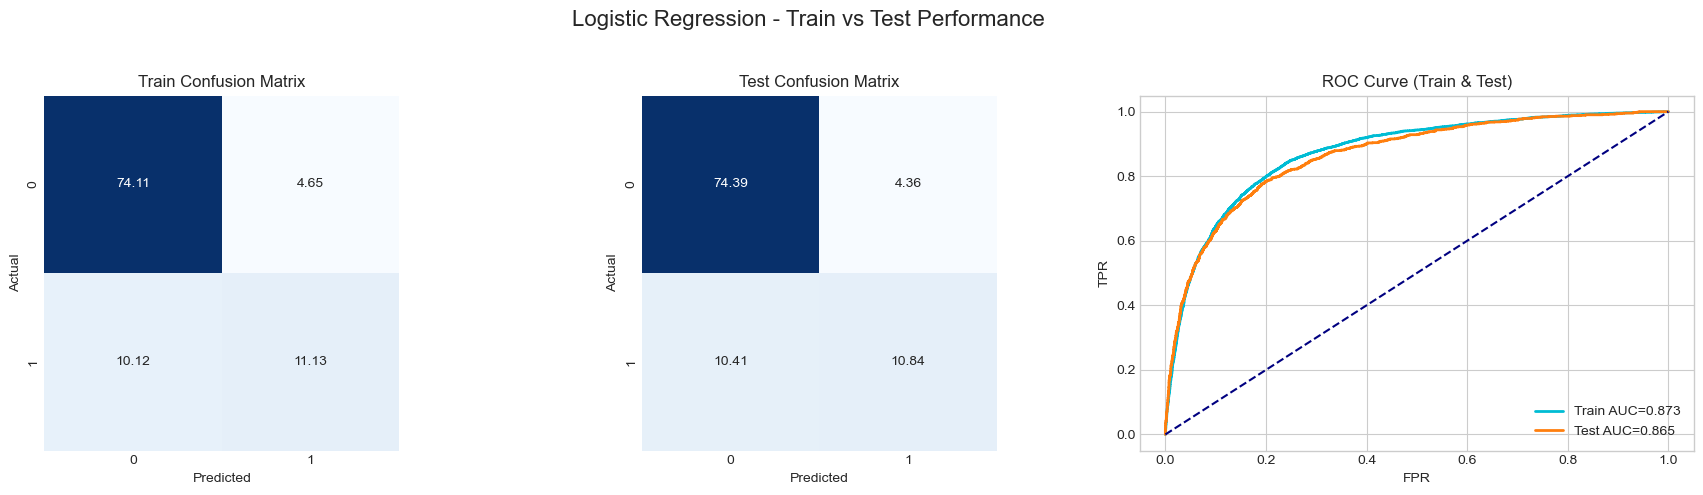

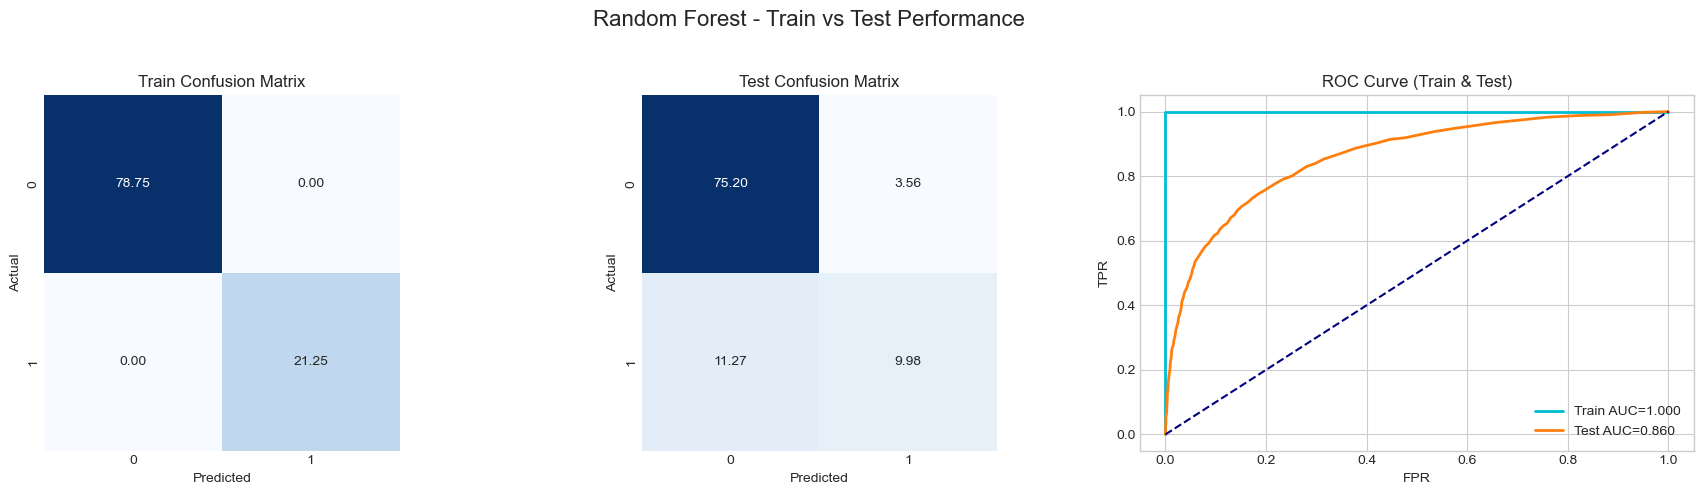

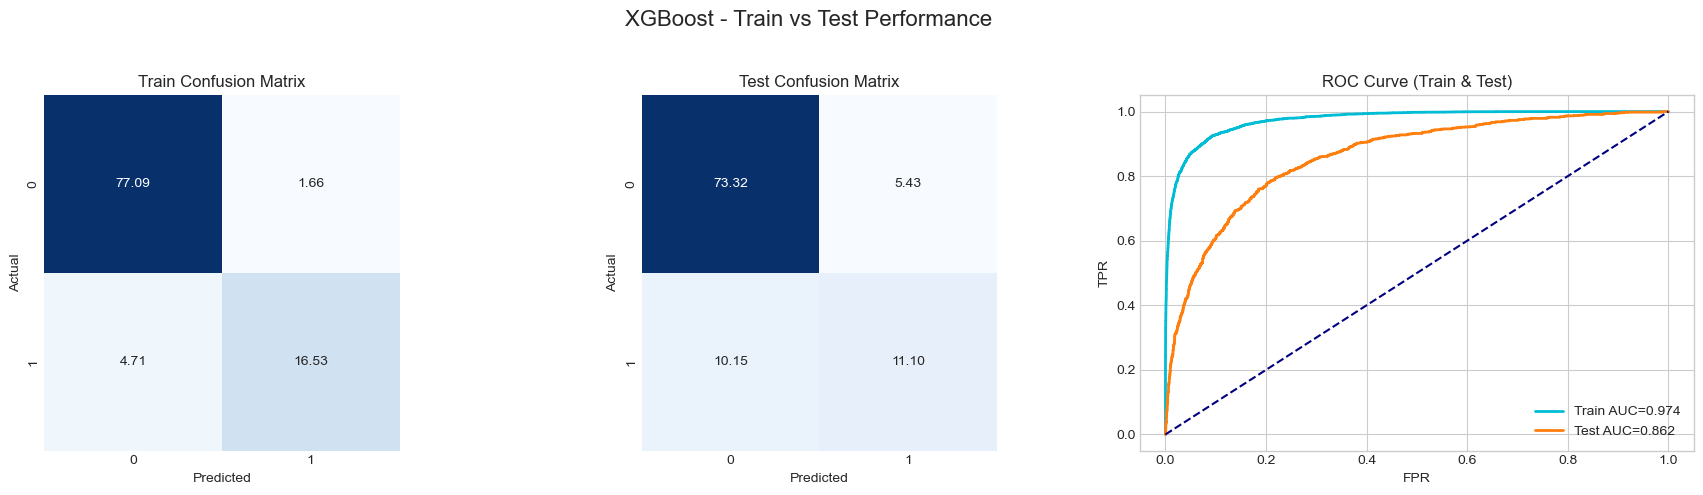

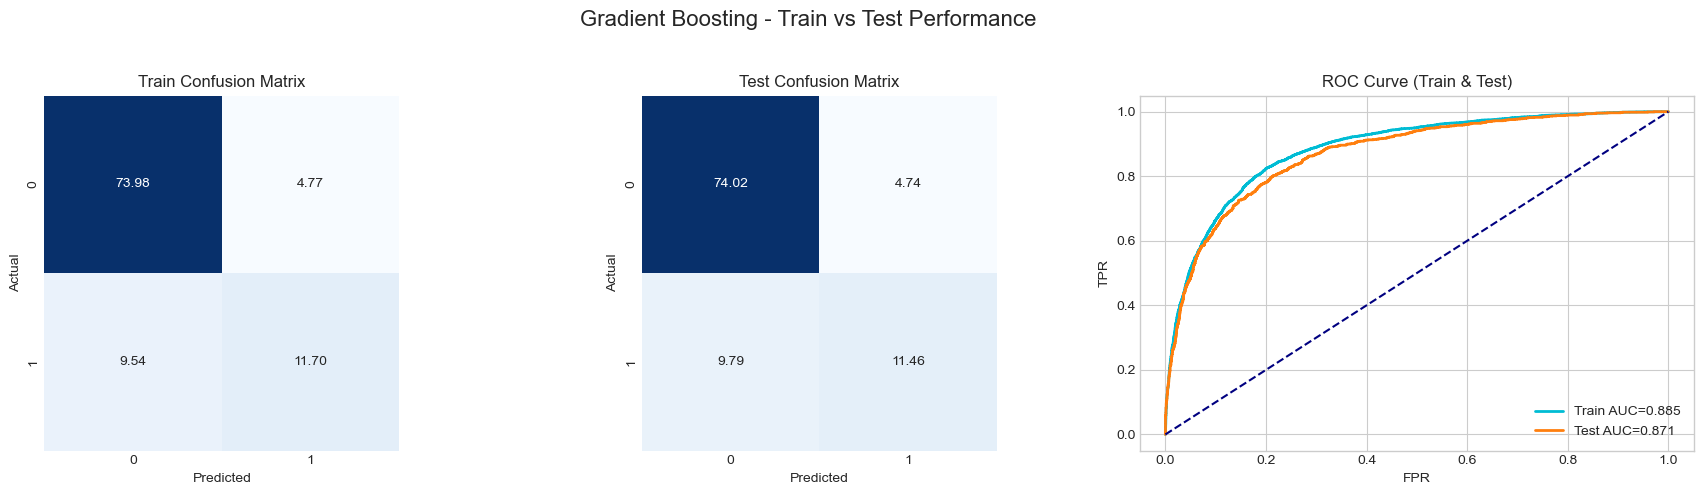

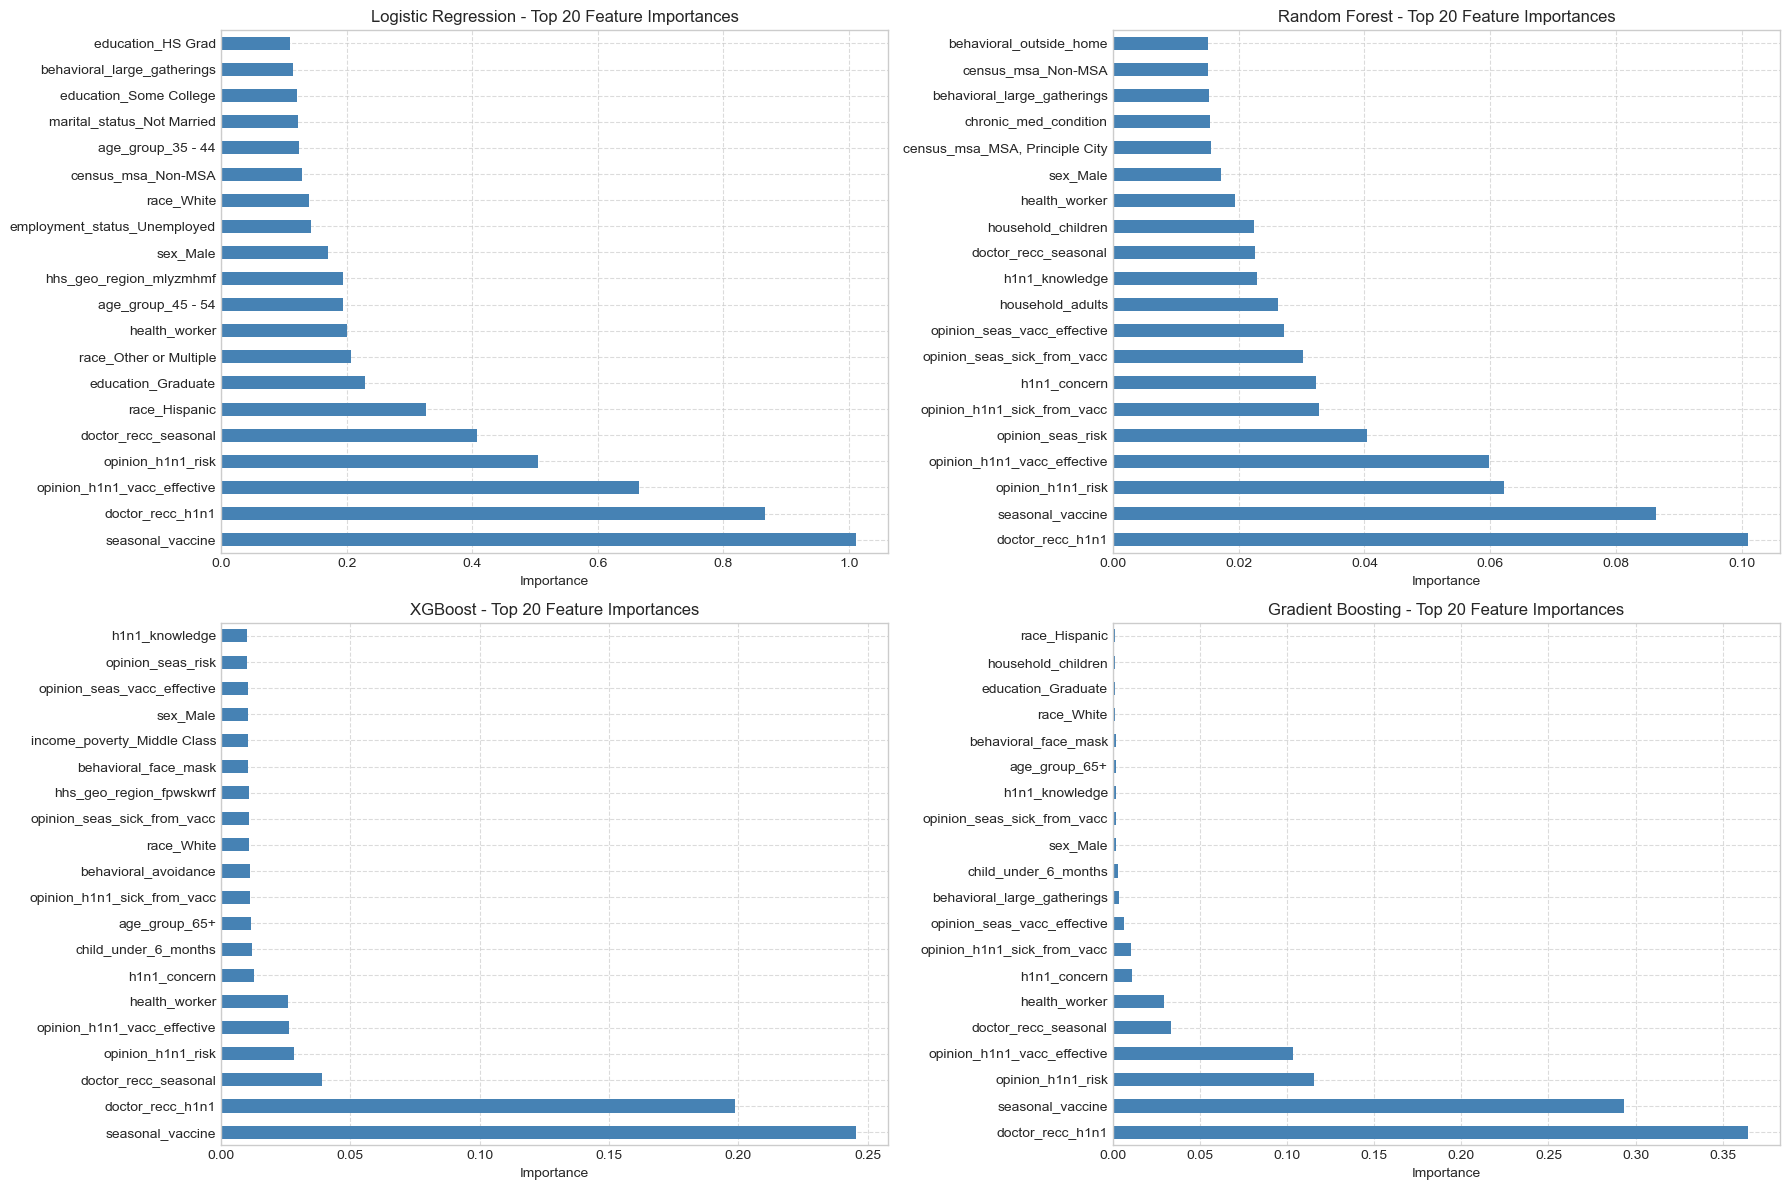

In [4]:
# PIPELINE-BASED MODEL TRAINING & EVALUATION

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)


# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models and store metrics
for name, clf in models.items():

    # Pipeline with preprocessing
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)

    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred

    # Compute metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # Save top 20 feature importances
    final_model = pipeline.named_steps['model']
    try:
        if hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=df_processed.columns).sort_values(ascending=False)[:20]
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=df_processed.columns).sort_values(ascending=False)[:20]
        else:
            importances = pd.Series([0]*len(df_processed.columns), index=df_processed.columns)
    except:
        importances = pd.Series([0]*len(df_processed.columns), index=df_processed.columns)
    
    feature_importances[name] = importances


# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)


# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance", fontsize=16)
    
    # Confusion matrices as percentages
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    # Combined ROC
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## DEALING WITH CLASS IMBALANCE

### 1. USING CLASS WEIGHTS

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.796667,0.790341,0.848586,0.842821,0.796667,0.790341,0.810815,0.804926,0.873921,0.865795
1,Random Forest,1.000000,0.853051,1.000000,0.843572,1.000000,0.853051,1.000000,0.838742,1.000000,0.862393
2,Gradient Boosting,0.856815,0.854736,0.848444,0.845857,0.856815,0.854736,0.849867,0.847189,0.884956,0.871390
3,XGBoost,0.915746,0.818794,0.931048,0.838506,0.915746,0.818794,0.919348,0.825942,0.978395,0.855845


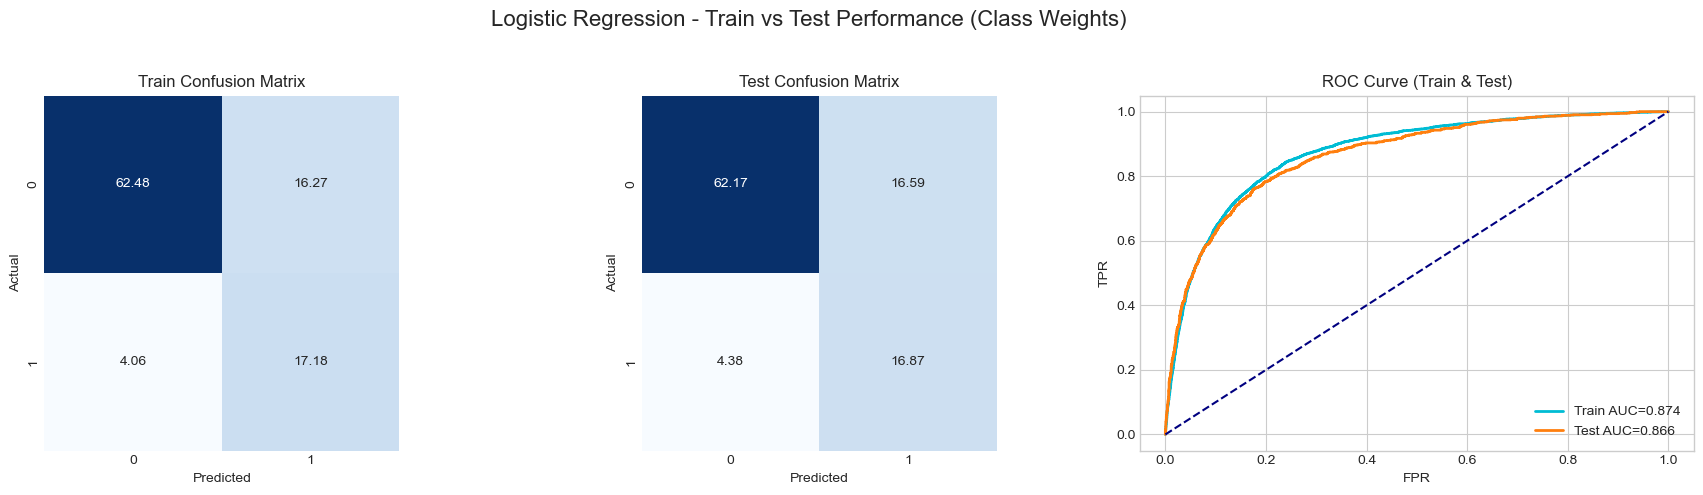

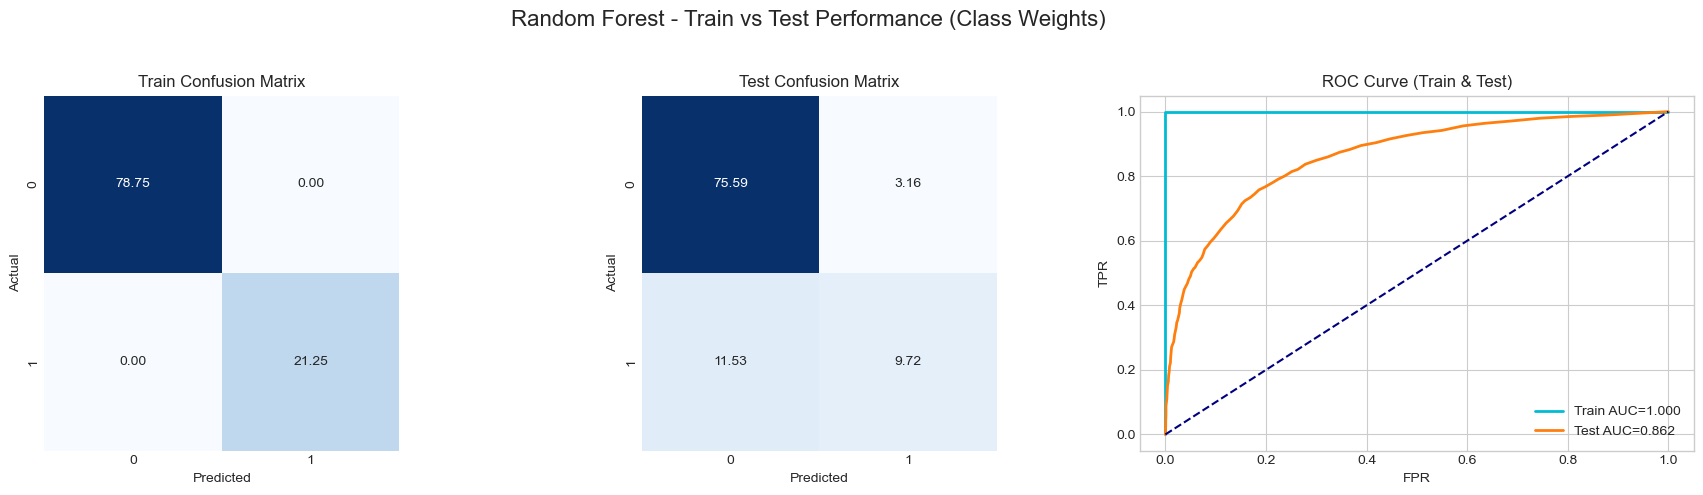

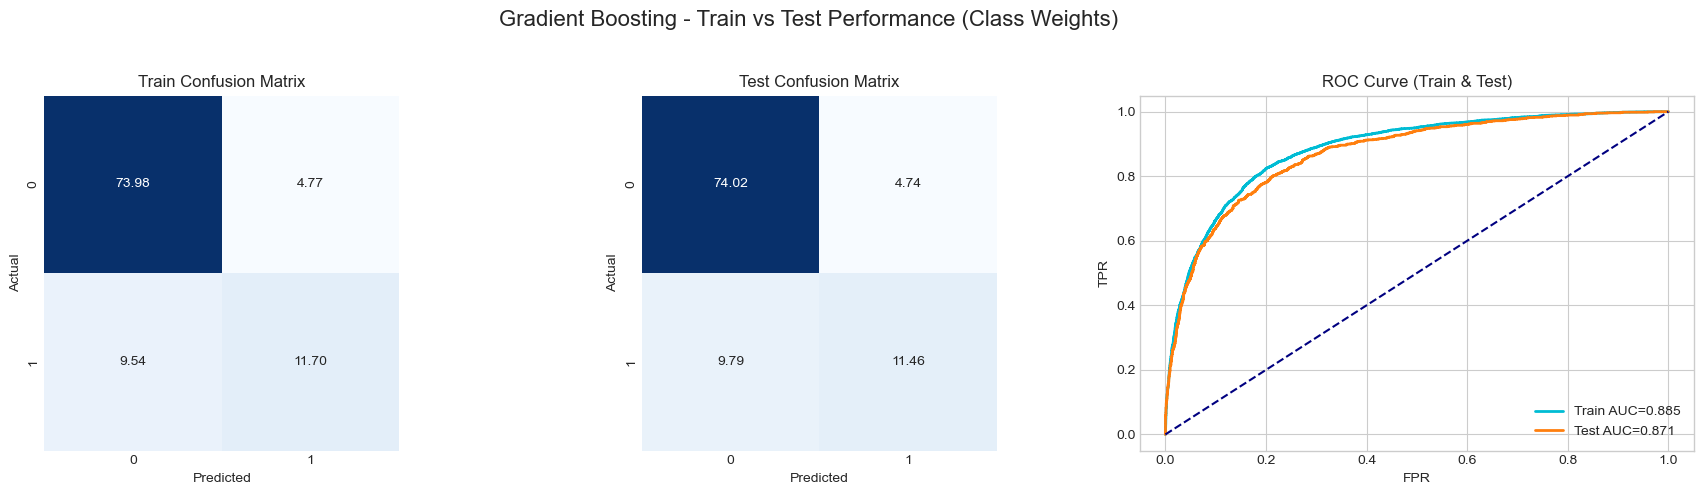

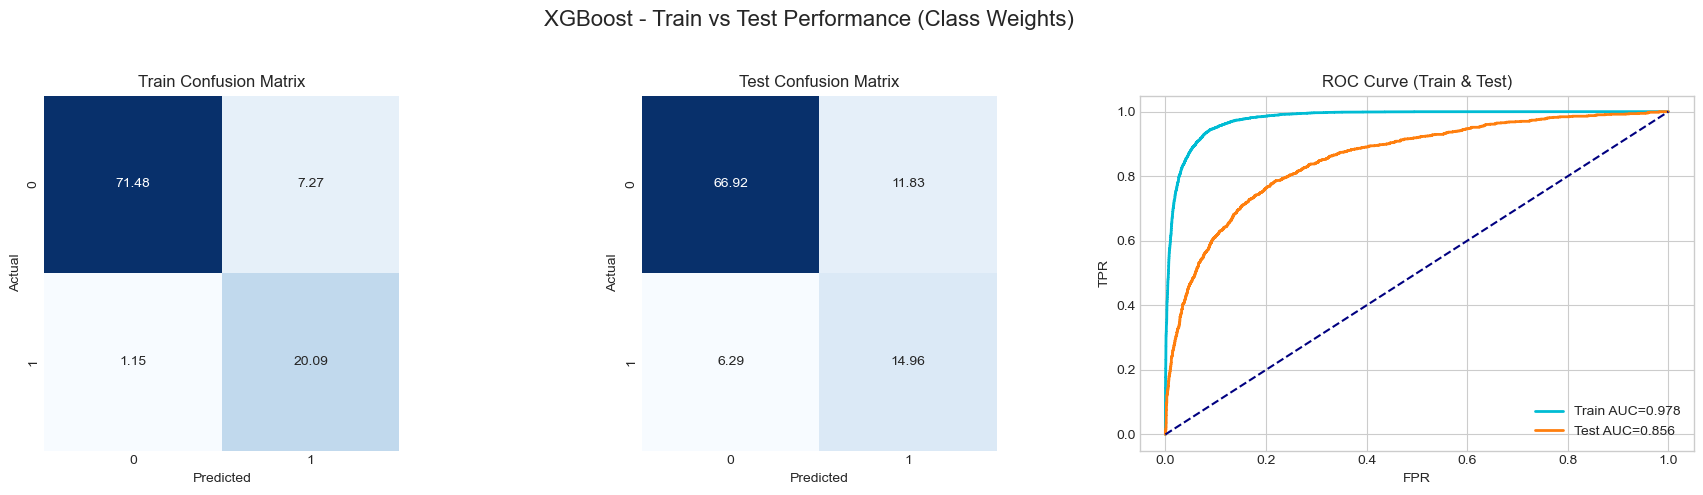

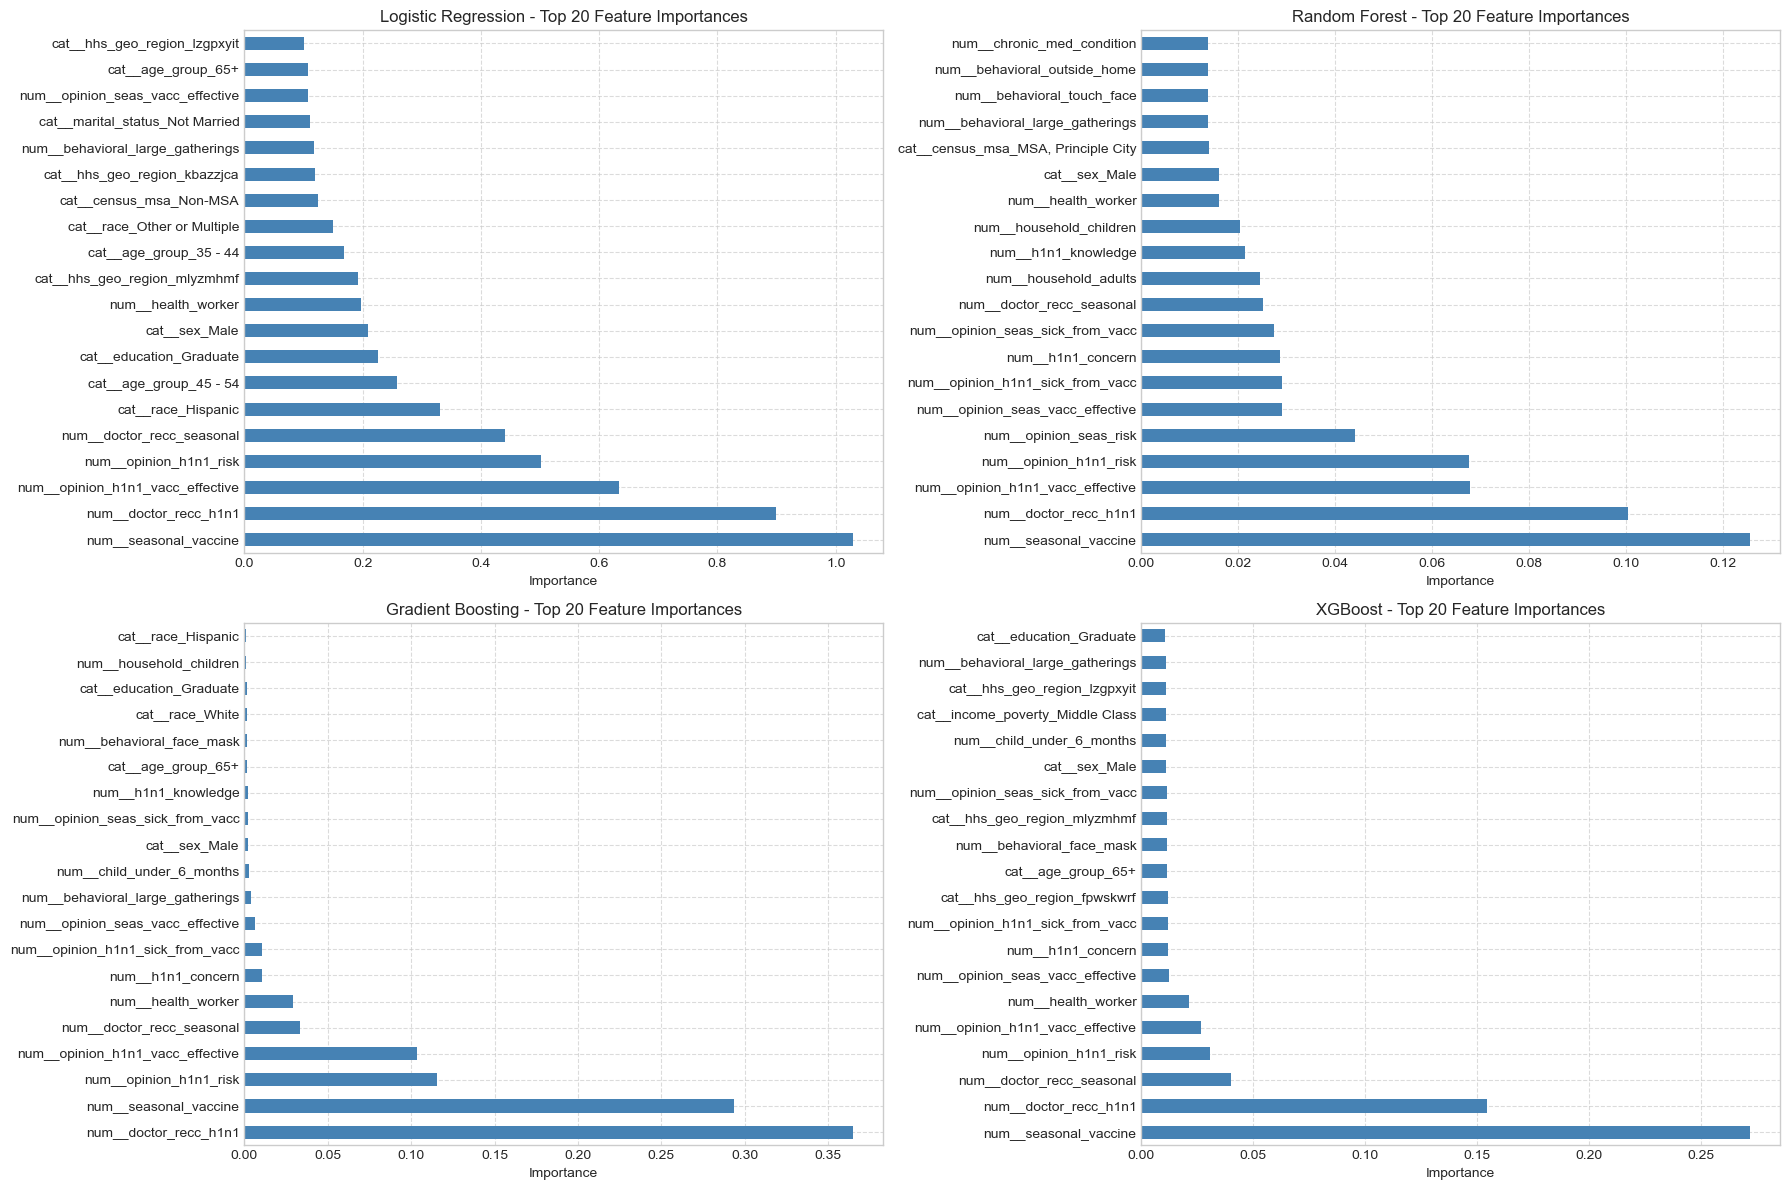

In [ ]:
# CLASS IMBALANCE HANDLING VIA CLASS WEIGHTS

# Compute XGBoost scale_pos_weight
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Define models with class weighting
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42), 
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)


# Containers
metrics_summary = []
plot_data = []
feature_importances = {}


# Fit models and compute metrics
for name, clf in models.items():
    
    pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    

    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    # get feature names from pipeline
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        # tree-based models
        if hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)[:20]
        
        # linear models
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names).sort_values(ascending=False)[:20]
        
        # fallback
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (Class Weights)", fontsize=16)
    
    # Confusion matrices as percentages
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    # ROC curve
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 2. USING SMOTE

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,Logistic Regression,0.796527,0.795021,0.846439,0.843015,0.796527,0.795021,0.810406,0.808703,0.872586,0.864536
1,Random Forest,1.000000,0.854549,1.000000,0.844890,1.000000,0.854549,1.000000,0.844671,1.000000,0.863164
2,Gradient Boosting,0.852883,0.847997,0.846568,0.840344,0.852883,0.847997,0.848728,0.842733,0.881211,0.868800
3,XGBoost,0.922112,0.850056,0.920175,0.841258,0.922112,0.850056,0.919769,0.843305,0.962787,0.861747


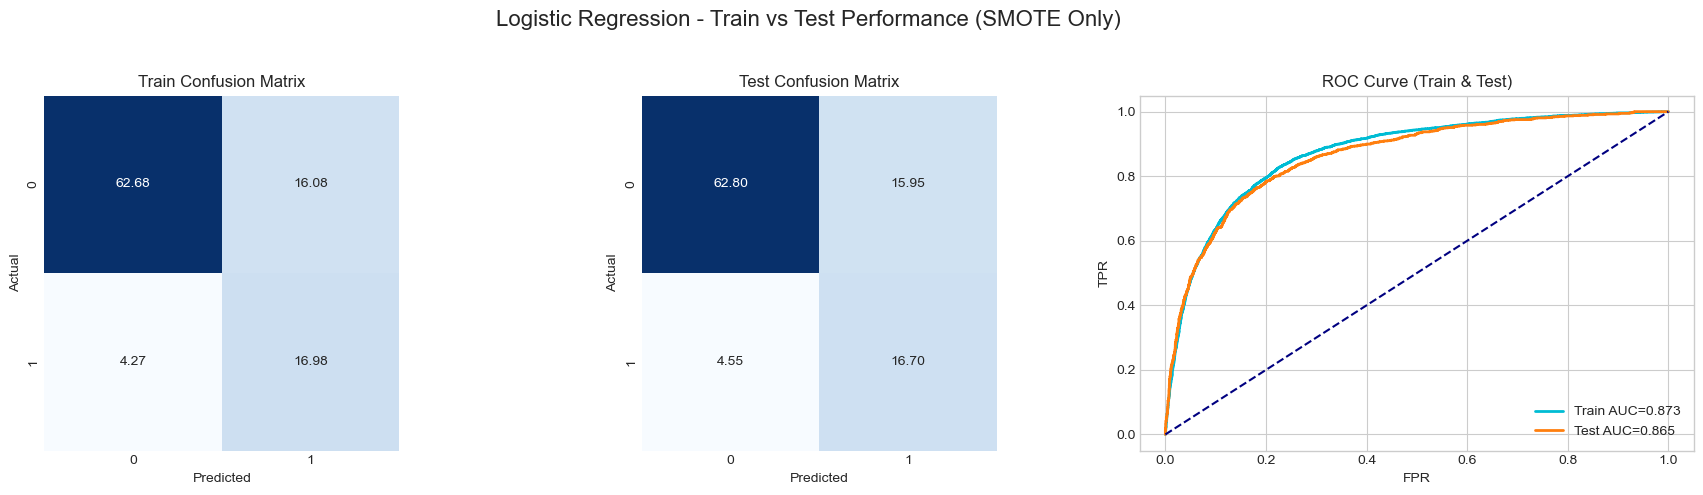

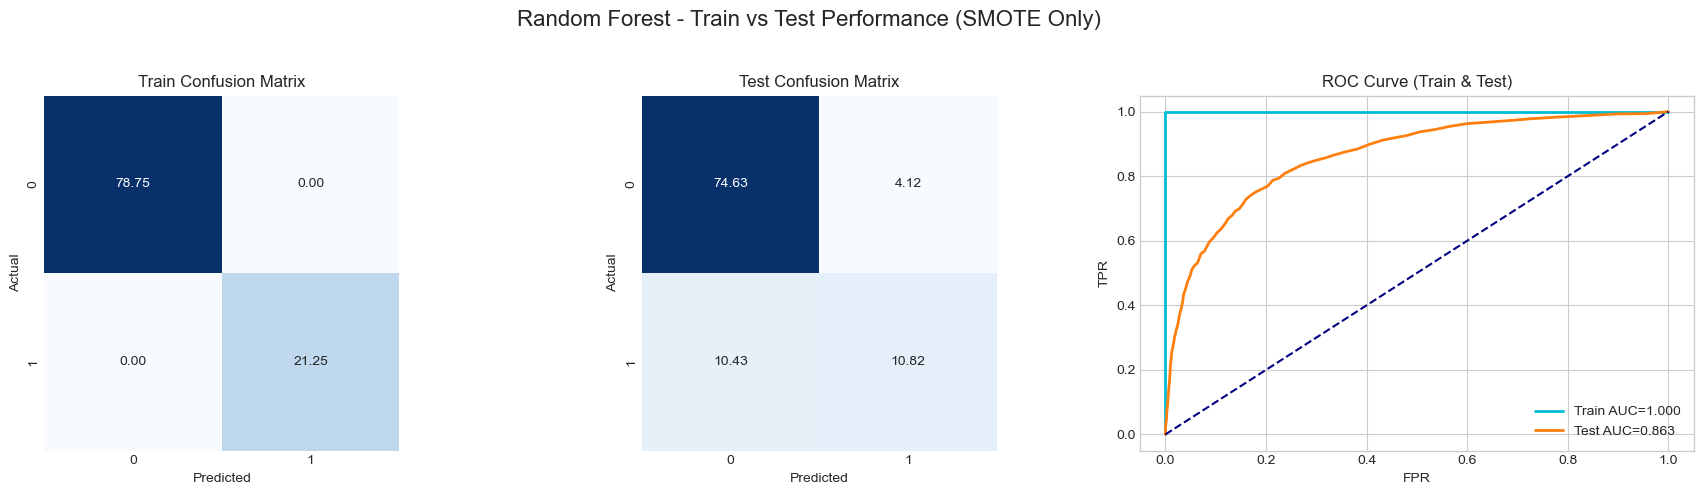

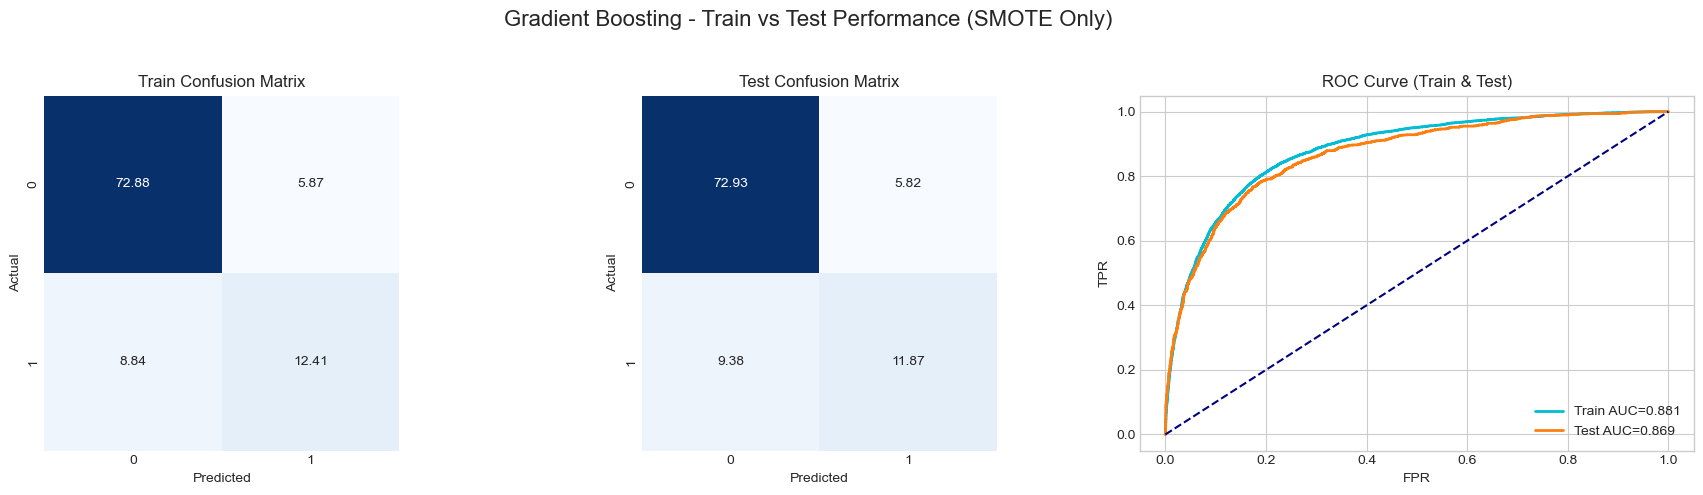

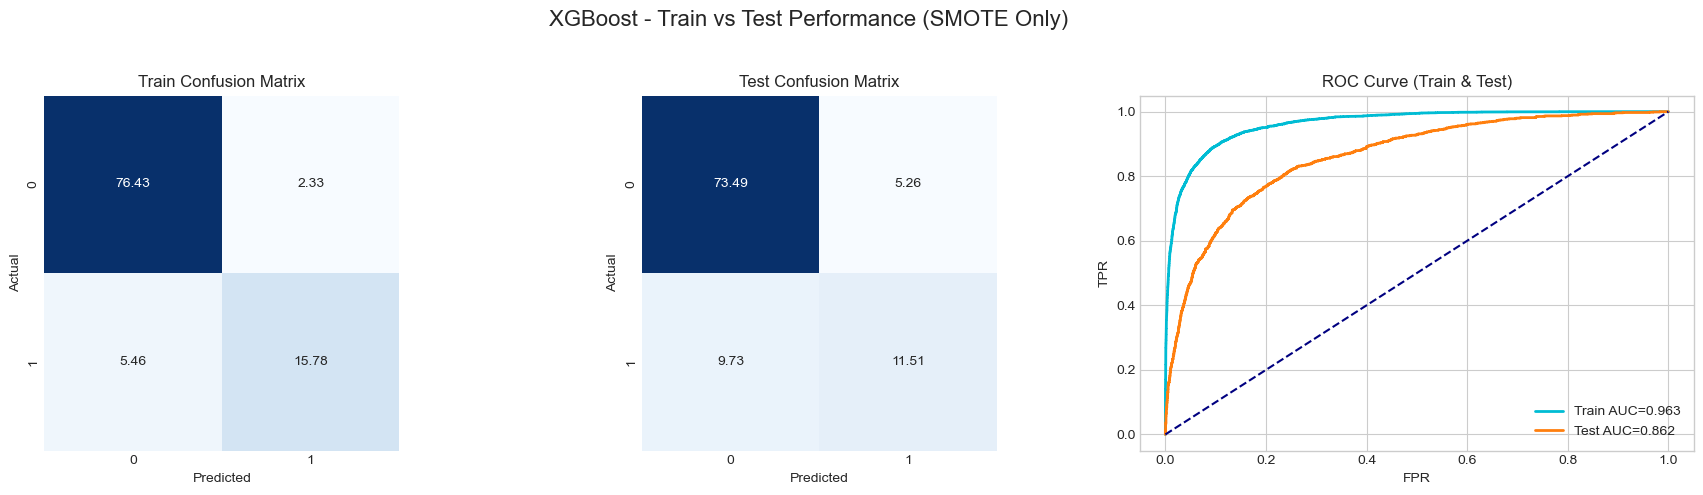

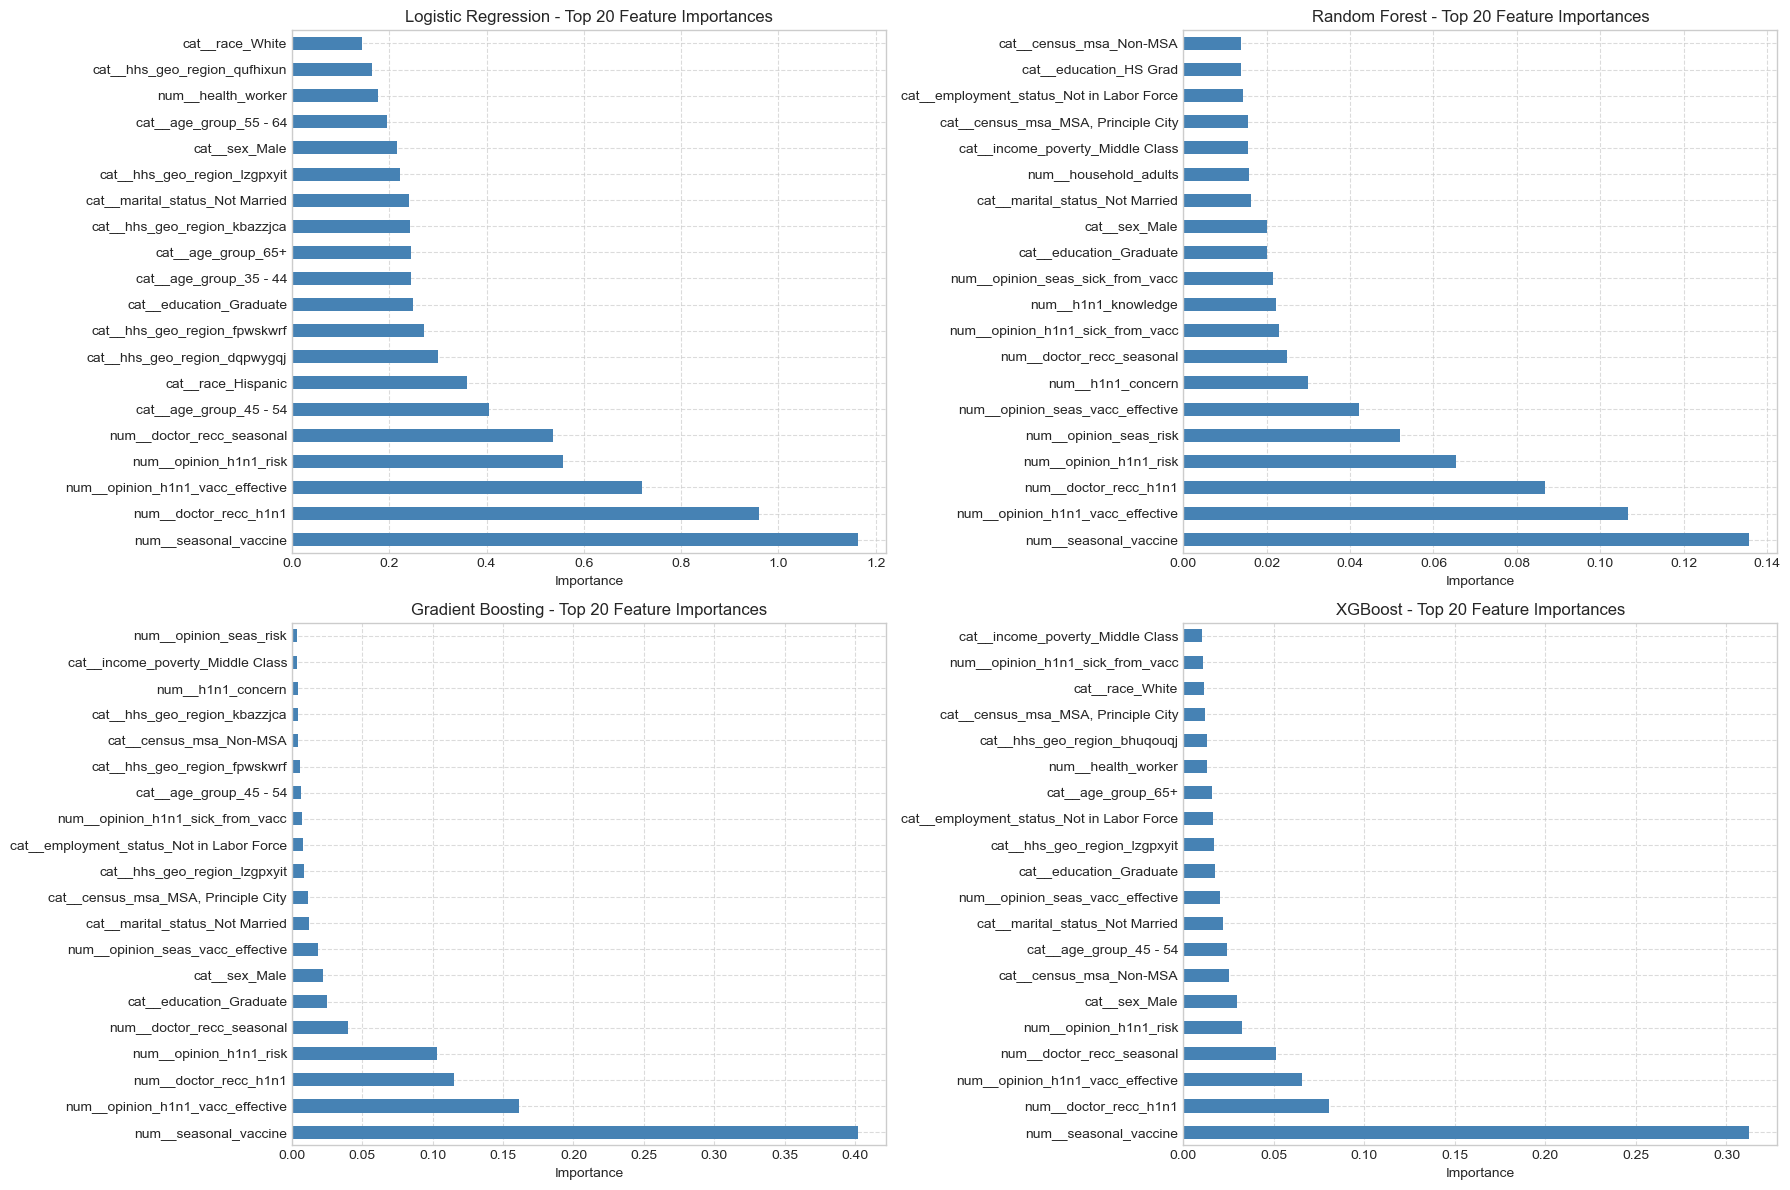

In [ ]:
# Define models 
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
}

# Helper function to compute metrics
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    metrics = {
        'accuracy': report['accuracy'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': roc_auc
    }
    return metrics, cm, (fpr, tpr, roc_auc)

# Containers
metrics_summary = []
plot_data = []
feature_importances = {}

# Fit models with SMOTE and compute metrics
for name, clf in models.items():
    
    # Imbalanced pipeline with SMOTE
    pipeline = ImbPipeline([
        ('preprocess', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', clf)
    ])
    
    pipeline.fit(X_train, y_train)
    
    # Predictions & probabilities
    y_train_pred = pipeline.predict(X_train)
    y_test_pred  = pipeline.predict(X_test)
    
    if hasattr(clf, "predict_proba"):
        y_train_prob = pipeline.predict_proba(X_train)[:,1]
        y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    elif hasattr(clf, "decision_function"):
        y_train_prob = pipeline.decision_function(X_train)
        y_test_prob  = pipeline.decision_function(X_test)
    else:
        y_train_prob = y_train_pred
        y_test_prob  = y_test_pred
    
    # Metrics
    train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
    test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
    # Save metrics
    metrics_summary.append({
        'Model': name,
        'Train Accuracy': train_metrics['accuracy'],
        'Test Accuracy': test_metrics['accuracy'],
        'Train Precision': train_metrics['precision'],
        'Test Precision': test_metrics['precision'],
        'Train Recall': train_metrics['recall'],
        'Test Recall': test_metrics['recall'],
        'Train F1': train_metrics['f1'],
        'Test F1': test_metrics['f1'],
        'Train ROC-AUC': train_metrics['roc_auc'],
        'Test ROC-AUC': test_metrics['roc_auc']
    })
    
    # Save plot data
    plot_data.append((name, train_cm, test_cm, train_roc, test_roc))
    
    # FEATURE IMPORTANCES
    final_model = pipeline.named_steps['model']
    
    # get feature names from pipeline
    feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
    
    try:
        # tree-based models
        if hasattr(final_model, 'feature_importances_'):
            importances = pd.Series(final_model.feature_importances_, index=feature_names).sort_values(ascending=False)[:20]
        
        # linear models
        elif hasattr(final_model, 'coef_'):
            importances = pd.Series(np.abs(final_model.coef_[0]), index=feature_names).sort_values(ascending=False)[:20]
        
        # fallback
        else:
            importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    except:
        importances = pd.Series([0]*len(feature_names), index=feature_names)
    
    feature_importances[name] = importances

# Display metrics table
metrics_df = pd.DataFrame(metrics_summary)
metrics_df = metrics_df[['Model','Train Accuracy','Test Accuracy',
                         'Train Precision','Test Precision',
                         'Train Recall','Test Recall',
                         'Train F1','Test F1',
                         'Train ROC-AUC','Test ROC-AUC']]
display(metrics_df)

# Plot confusion matrices & ROC curves
for name, train_cm, test_cm, train_roc, test_roc in plot_data:
    fig, axes = plt.subplots(1, 3, figsize=(18,5))
    fig.suptitle(f"{name} - Train vs Test Performance (SMOTE Only)", fontsize=16)
    
    # Confusion matrices as percentages
    train_cm_pct = train_cm / train_cm.sum() * 100
    test_cm_pct  = test_cm / test_cm.sum() * 100
    
    sns.heatmap(train_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[0])
    axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    sns.heatmap(test_cm_pct, annot=True, fmt=".2f", cmap='Blues', cbar=False, square=True, ax=axes[1])
    axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
    
    # ROC curve
    ax = axes[2]
    fpr_train, tpr_train, auc_train = train_roc
    fpr_test, tpr_test, auc_test = test_roc
    ax.plot(fpr_train, tpr_train, lw=2, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
    ax.plot(fpr_test, tpr_test, lw=2, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
    ax.plot([0,1],[0,1],'--', color='navy')
    ax.set(title='ROC Curve (Train & Test)', xlabel='FPR', ylabel='TPR')
    ax.legend(loc='lower right')
    
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Plot top 20 feature importances
rows, cols = 2, 2
fig, axes = plt.subplots(rows, cols, figsize=(18,12))
axes = axes.flatten()

for i, (name, importances) in enumerate(feature_importances.items()):
    importances.sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(f"{name} - Top 20 Feature Importances", fontsize=12)
    axes[i].set_xlabel('Importance')
    axes[i].invert_yaxis()
    axes[i].grid(axis='both', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## HYPERPARAMETER TUNING

[I 2025-11-26 21:09:37,417] A new study created in memory with name: no-name-70c90373-ecb6-4cea-b746-10e17778038d
[I 2025-11-26 21:09:38,345] Trial 0 finished with value: 0.6011309264897782 and parameters: {'n_estimators': 194, 'max_depth': 8, 'learning_rate': 0.21064939113507655, 'subsample': 0.6611264129247422, 'colsample_bytree': 0.9948893196974313}. Best is trial 0 with value: 0.6011309264897782.
[I 2025-11-26 21:09:39,690] Trial 1 finished with value: 0.6062992125984252 and parameters: {'n_estimators': 399, 'max_depth': 7, 'learning_rate': 0.1726246418157986, 'subsample': 0.8313375178852529, 'colsample_bytree': 0.8714327081654085}. Best is trial 1 with value: 0.6062992125984252.
[I 2025-11-26 21:09:41,009] Trial 2 finished with value: 0.6106467223933129 and parameters: {'n_estimators': 378, 'max_depth': 7, 'learning_rate': 0.25098086883388815, 'subsample': 0.8512135701873342, 'colsample_bytree': 0.8064049675400861}. Best is trial 2 with value: 0.6106467223933129.
[I 2025-11-26 21:

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Train ROC-AUC,Test ROC-AUC
0,RandomizedSearchCV,0.836828,0.810932,0.872906,0.846507,0.836828,0.810932,0.846630,0.821807,0.914134,0.872746
1,Optuna,0.922861,0.827967,0.935154,0.845116,0.922861,0.827967,0.925820,0.834239,0.982594,0.867185
2,GridSearchCV,0.885415,0.813927,0.908691,0.841279,0.885415,0.813927,0.891235,0.823046,0.960462,0.867729


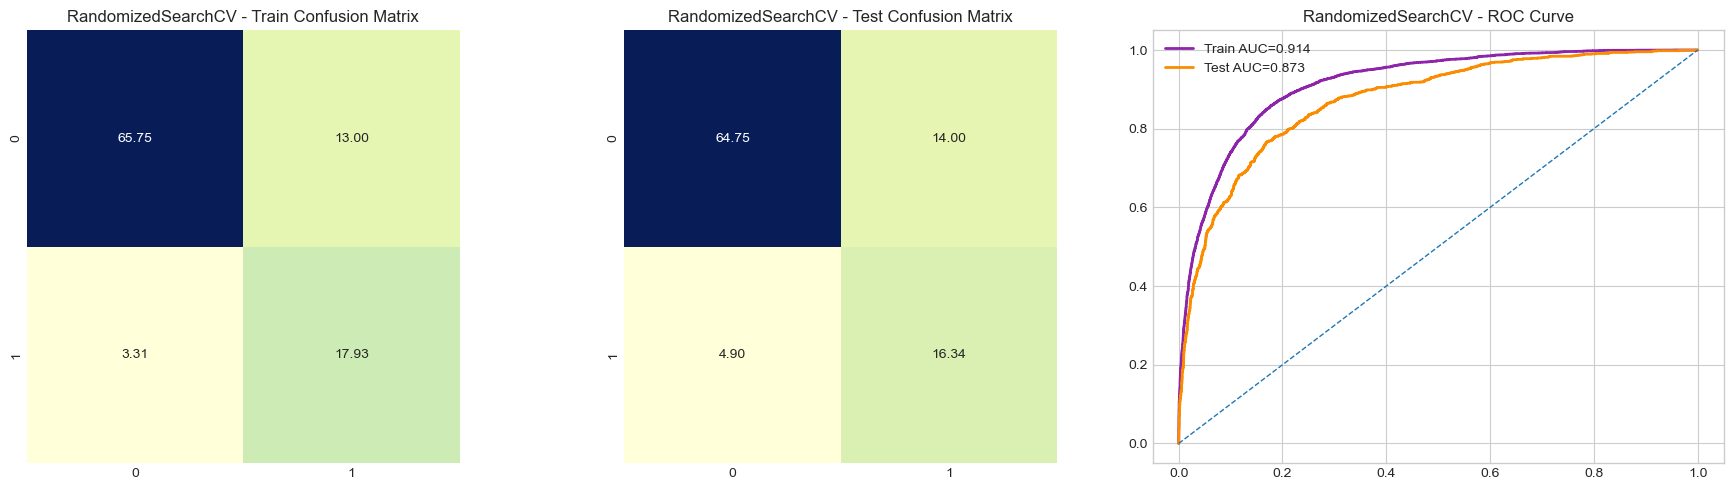

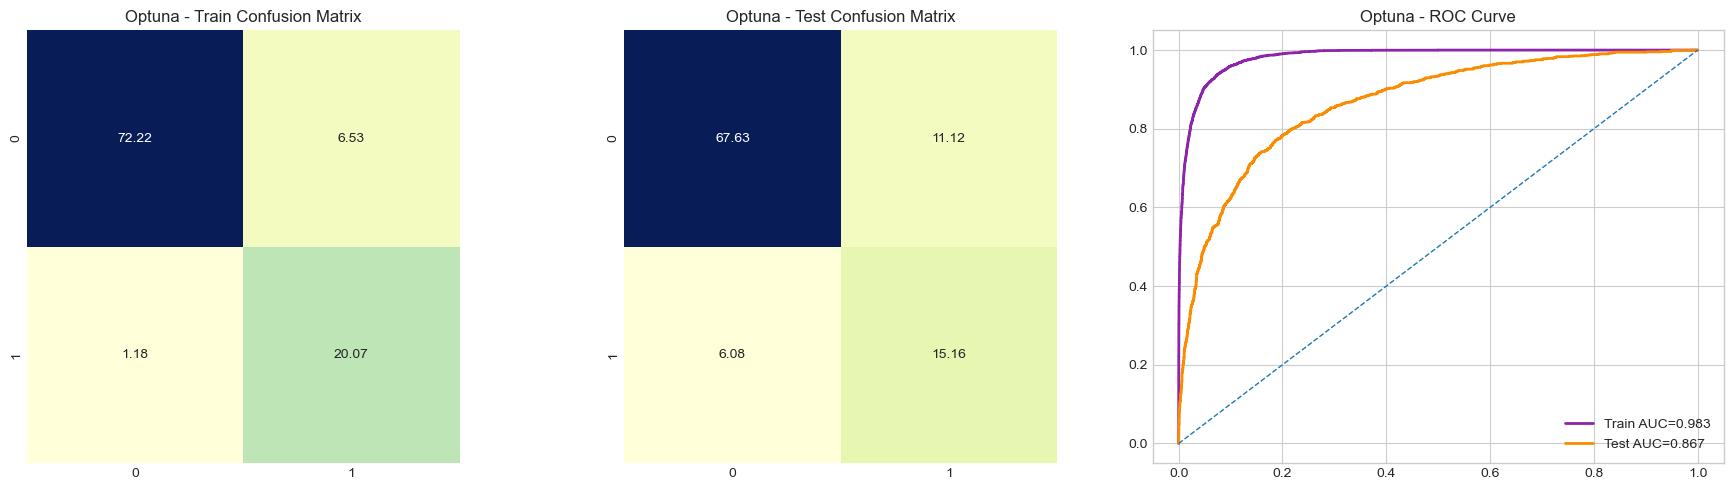

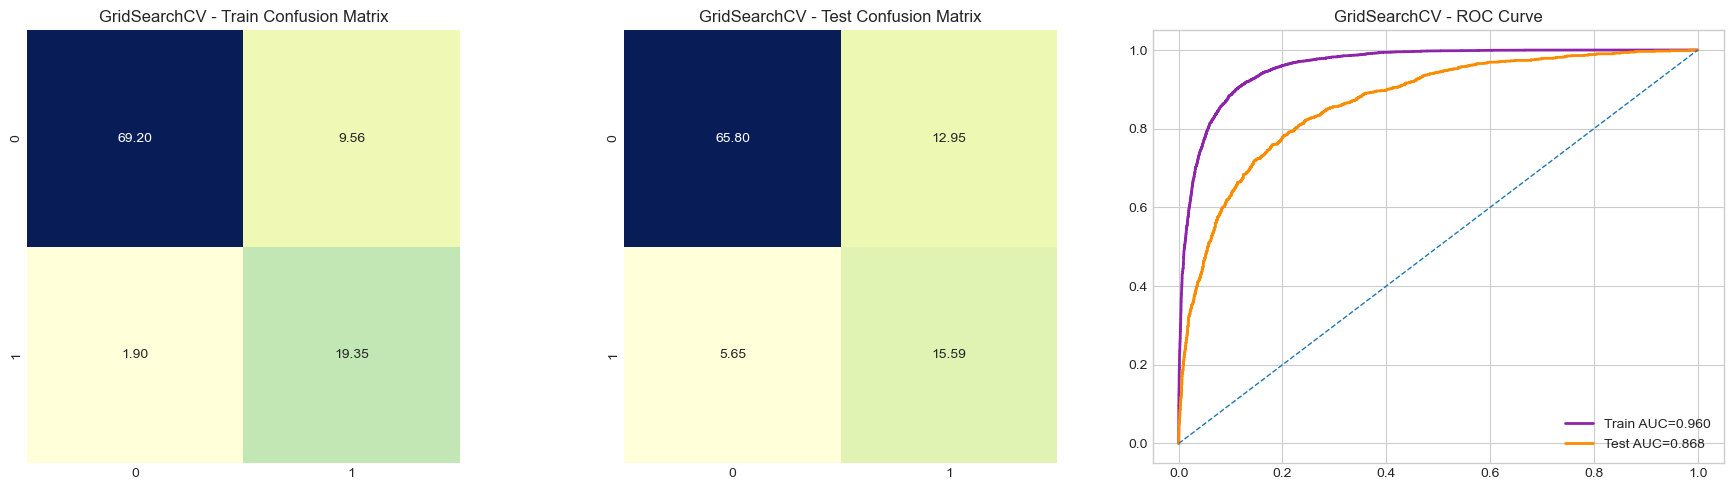

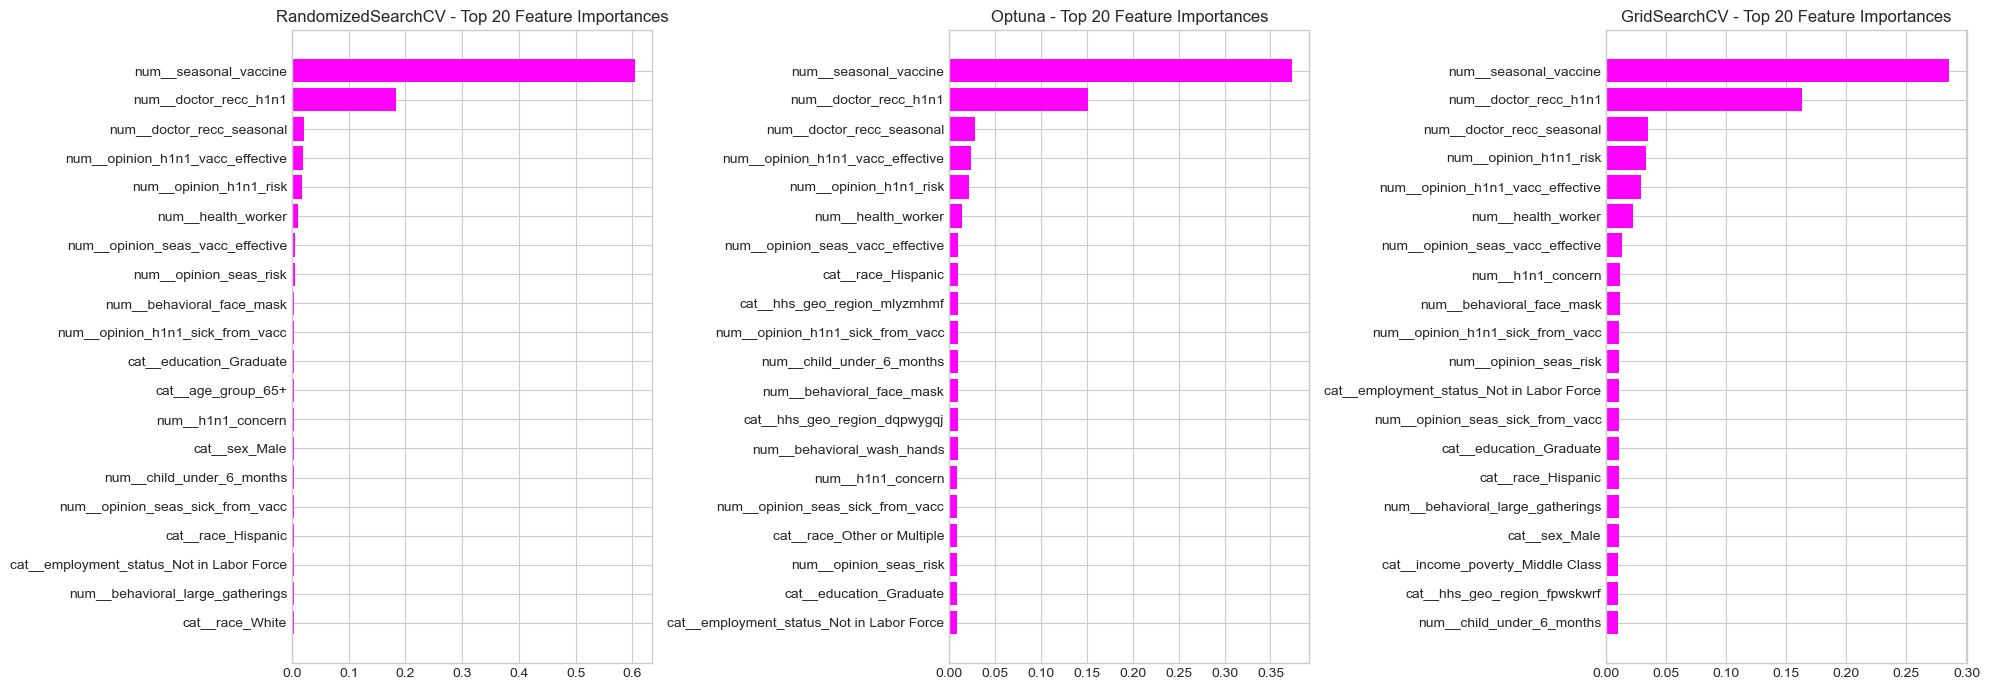

In [11]:
# ============================================================
#  FULL DEPLOY-READY PIPELINE WITH TUNING + EVALUATION
# ============================================================

import joblib

# ===================================================================
# CLASS WEIGHTS
# ===================================================================
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# ===================================================================
# HELPERS — METRICS, ROC, CONFUSION MATRIX
# ===================================================================
def compute_metrics(y_true, y_pred, y_prob):
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    roc_val = auc(fpr, tpr)

    metrics = {
        "accuracy": report["accuracy"],
        "precision": report["weighted avg"]["precision"],
        "recall": report["weighted avg"]["recall"],
        "f1": report["weighted avg"]["f1-score"],
        "roc_auc": roc_val
    }
    return metrics, cm, (fpr, tpr, roc_val)


# ===================================================================
# EVALUATION — NOW PIPELINE-COMPATIBLE WITH PREPROCESSOR
# ===================================================================
def evaluate_model(pipeline, X_train, y_train, X_test, y_test, name):

    # predictions
    y_tr_pred = pipeline.predict(X_train)
    y_te_pred = pipeline.predict(X_test)
    y_tr_prob = pipeline.predict_proba(X_train)[:, 1]
    y_te_prob = pipeline.predict_proba(X_test)[:, 1]

    tr_metrics, tr_cm, tr_roc = compute_metrics(y_train, y_tr_pred, y_tr_prob)
    te_metrics, te_cm, te_roc = compute_metrics(y_test, y_te_pred, y_te_prob)

    metrics = {
        'Model': name,
        'Train Accuracy': tr_metrics['accuracy'],
        'Test Accuracy': te_metrics['accuracy'],
        'Train Precision': tr_metrics['precision'],
        'Test Precision': te_metrics['precision'],
        'Train Recall': tr_metrics['recall'],
        'Test Recall': te_metrics['recall'],
        'Train F1': tr_metrics['f1'],
        'Test F1': te_metrics['f1'],
        'Train ROC-AUC': tr_metrics['roc_auc'],
        'Test ROC-AUC': te_metrics['roc_auc']
    }

    # ================================================================
    # CORRECT FEATURE IMPORTANCES (after ColumnTransformer)
    # ================================================================

    model = pipeline.named_steps['model']
    importances = model.feature_importances_

    # Extract transformed feature names from preprocessor
    try:
        feature_names = (
            pipeline.named_steps['preprocess']
            .get_feature_names_out()
        )
    except:
        feature_names = np.arange(len(importances))

    fi = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(20)

    return metrics, tr_cm, te_cm, tr_roc, te_roc, fi


# ===================================================================
# BASE XGBOOST INSIDE PIPELINE
# ===================================================================
base_pipe = Pipeline([
    ('preprocess', preprocessor),
    ('model', XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ))
])


# ===================================================================
# RANDOMIZED SEARCH
# ===================================================================
f1_scorer = make_scorer(f1_score, pos_label=1)

param_dist = {
    'model__n_estimators': [100, 200, 250],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

rand_search = RandomizedSearchCV(
    base_pipe, param_distributions=param_dist, n_iter=30,
    cv=5, scoring=f1_scorer, random_state=42
)
rand_search.fit(X_train, y_train)
best_random = rand_search.best_params_


# ===================================================================
# OPTUNA TUNING (PIPELINE-COMPATIBLE)
# ===================================================================
def optuna_objective(trial):

    params = {
        'model__n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'model__max_depth': trial.suggest_int('max_depth', 3, 10),
        'model__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'model__subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'model__colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }

    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            random_state=42, use_label_encoder=False, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight
        ))
    ])
    pipe.set_params(**params)
    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)
    return f1_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=30, show_progress_bar=True)

best_optuna = {
    f"model__{k}": v for k, v in study.best_params.items()
}


# ===================================================================
# GRID SEARCH ON PIPELINE
# ===================================================================
grid_params = {
    'model__n_estimators': [100, 200, 250],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(base_pipe, param_grid=grid_params, cv=5, scoring=f1_scorer)
grid_search.fit(X_train, y_train)
best_grid = grid_search.best_params_


# ===================================================================
# BUILD FINAL MODELS
# ===================================================================
def build_pipeline(best_params):
    pipe = Pipeline([
        ('preprocess', preprocessor),
        ('model', XGBClassifier(
            random_state=42, use_label_encoder=False, eval_metric='logloss',
            scale_pos_weight=scale_pos_weight
        ))
    ])
    pipe.set_params(**best_params)
    pipe.fit(X_train, y_train)
    return pipe

models = {
    'RandomizedSearchCV': build_pipeline(best_random),
    'Optuna': build_pipeline(best_optuna),
    'GridSearchCV': build_pipeline(best_grid)
}

# ===================================================================
# FULL EVALUATION
# ===================================================================
results = {
    name: evaluate_model(model, X_train, y_train, X_test, y_test, name)
    for name, model in models.items()
}

metrics_df = pd.DataFrame([res[0] for res in results.values()])
display(metrics_df)


# ===================================================================
# PLOTS (CM + ROC)
# ===================================================================
def plot_separate_figures(results_dict):
    for name, res in results_dict.items():
        train_cm = res[1] / res[1].sum() * 100
        test_cm = res[2] / res[2].sum() * 100
        fpr_tr, tpr_tr, auc_tr = res[3]
        fpr_te, tpr_te, auc_te = res[4]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        sns.heatmap(train_cm, annot=True, fmt='.2f', cmap='YlGnBu',
                    cbar=False, square=True, ax=axes[0])
        axes[0].set_title(f'{name} - Train Confusion Matrix')

        sns.heatmap(test_cm, annot=True, fmt='.2f', cmap='YlGnBu',
                    cbar=False, square=True, ax=axes[1])
        axes[1].set_title(f'{name} - Test Confusion Matrix')

        axes[2].plot(fpr_tr, tpr_tr, lw=2, label=f'Train AUC={auc_tr:.3f}', color='#8e24aa')
        axes[2].plot(fpr_te, tpr_te, lw=2, label=f'Test AUC={auc_te:.3f}', color='#fb8c00')
        axes[2].plot([0, 1], [0, 1], '--', linewidth=1)
        axes[2].set_title(f'{name} - ROC Curve')
        axes[2].legend()

        plt.tight_layout()
        plt.show()

plot_separate_figures(results)


# ===================================================================
# FEATURE IMPORTANCE PLOTS
# ===================================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for i, name in enumerate(['RandomizedSearchCV', 'Optuna', 'GridSearchCV']):
    fi = results[name][5].sort_values()
    axes[i].barh(fi.index, fi.values, color='magenta')
    axes[i].set_title(f'{name} - Top 20 Feature Importances')

plt.tight_layout()
plt.show()


# ===================================================================
# SAVE BEST MODEL FOR DEPLOYMENT
# ===================================================================
# best_model_name = metrics_df.sort_values("Test F1", ascending=False).iloc[0]["Model"]
# best_model = models[best_model_name]

# joblib.dump(best_model, "best_xgb_pipeline.pkl")
# print(f"Saved best model: {best_model_name}")


In [7]:
# BASE PIPELINE (Shared Preprocessing)
# ==============================================================

gb_clf = GradientBoostingClassifier(random_state=42)

pipeline = ImbPipeline([
    ("preprocess", preprocessor),  
    ("model", gb_clf)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# ==============================================================
# 2. RANDOMIZED SEARCH (Independent search)
# ==============================================================

param_dist = {
    "model__n_estimators": [50, 100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 5, 8],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__max_features": ["sqrt", "log2", None]
}

rand_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=30,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search.fit(X_train, y_train)

print("\n[RandomizedSearchCV] Best Parameters")
print(rand_search.best_params_)
print(f"Best F1 Score: {rand_search.best_score_:.4f}")


# ==============================================================
# 3. OPTUNA SEARCH (Independent search)
# ==============================================================

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 4),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

    clf = GradientBoostingClassifier(**params, random_state=42)

    p = ImbPipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        p.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        preds = p.predict(X_train.iloc[val_idx])
        scores.append(f1_score(y_train.iloc[val_idx], preds))

    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n[Optuna] Best Parameters")
print(study.best_params)
print(f"Best F1 Score: {study.best_value:.4f}")

optuna_model = ImbPipeline([
    ("preprocess", preprocessor),
    ("model", GradientBoostingClassifier(**study.best_params, random_state=42))
])


# ==============================================================
# 4. GRID SEARCH (Independent search)
# ==============================================================

param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__max_features": ["sqrt", "log2", None]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("\n[GridSearchCV] Best Parameters")
print(grid_search.best_params_)
print(f"Best F1 Score: {grid_search.best_score_:.4f}")


# ==============================================================
# 5. ALL MODELS (Fully tuned, independent)
# ==============================================================

tuned_models = {
    "RandomizedSearchCV": rand_search.best_estimator_,
    "Optuna": optuna_model,
    "GridSearchCV": grid_search.best_estimator_
}


# ==============================================================
# 6. EVALUATION FUNCTION (Plots + Metrics)
# ==============================================================

def evaluate_model(pipeline, X_train, y_train, X_test, y_test, name):

    pipeline.fit(X_train, y_train)

    # predictions
    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)

    y_train_prob = pipeline.predict_proba(X_train)[:, 1]
    y_test_prob = pipeline.predict_proba(X_test)[:, 1]

    # metrics
    f1_train = f1_score(y_train, y_train_pred)
    f1_test = f1_score(y_test, y_test_pred)

    auc_train = roc_auc_score(y_train, y_train_prob)
    auc_test = roc_auc_score(y_test, y_test_prob)

    print(f"\n{name}")
    print("=" * 60)
    print(f"F1 Train: {f1_train:.4f} | F1 Test: {f1_test:.4f}")
    print(f"AUC Train: {auc_train:.4f} | AUC Test: {auc_test:.4f}")

    # confusion matrices
    cm_train = confusion_matrix(y_train, y_train_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{name} - Train Confusion Matrix")

    sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", ax=axes[1])
    axes[1].set_title(f"{name} - Test Confusion Matrix")

    plt.show()

    # ROC curves
    fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
    fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr_train, tpr_train, label=f"Train AUC={auc_train:.3f}", linewidth=2)
    plt.plot(fpr_test, tpr_test, label=f"Test AUC={auc_test:.3f}", linewidth=2)
    plt.plot([0, 1], [0, 1], "--", color="black")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.show()

    # feature importances
    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    model = pipeline.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        imp = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False).head(20)

        plt.figure(figsize=(8, 7))
        imp.sort_values().plot(kind="barh")
        plt.title(f"{name} - Top 20 Feature Importances")
        plt.tight_layout()
        plt.show()

    return f1_test, auc_test


# ==============================================================
# 7. RUN AND COMPARE ALL MODELS
# ==============================================================

results = []

for name, model in tuned_models.items():
    f1_test, auc_test = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results.append({"Model": name, "F1 Test": f1_test, "AUC Test": auc_test})

comparison_df = pd.DataFrame(results).sort_values(by="F1 Test", ascending=False)
display(comparison_df)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


[I 2025-11-26 20:09:43,995] A new study created in memory with name: no-name-f953f603-6fde-4b95-bb25-7a6bba26b337



[RandomizedSearchCV] Best Parameters
{'model__subsample': 0.6, 'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': 3, 'model__learning_rate': 0.1}
Best F1 Score: 0.6079


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-11-26 20:09:50,320] Trial 0 finished with value: 0.5538596579475558 and parameters: {'n_estimators': 53, 'learning_rate': 0.16880177675889807, 'max_depth': 2, 'min_samples_split': 4, 'min_samples_leaf': 3, 'subsample': 0.9258493287264644, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.5538596579475558.
[I 2025-11-26 20:10:08,286] Trial 1 finished with value: 0.6035941822037947 and parameters: {'n_estimators': 114, 'learning_rate': 0.18013261193443092, 'max_depth': 4, 'min_samples_split': 5, 'min_samples_leaf': 3, 'subsample': 0.9422435641466672, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.6035941822037947.
[I 2025-11-26 20:10:31,745] Trial 2 finished with value: 0.5842269454584792 and parameters: {'n_estimators': 56, 'learning_rate': 0.10344396151570569, 'max_depth': 8, 'min_samples_split': 4, 'min_samples_leaf': 1, 'subsample': 0.7091838016178399, 'max_features': 'log2'}. Best is trial 1 with value: 0.6035941822037947.
[I 2025-11-26 20:10:48,966] Trial 3 fin

KeyboardInterrupt: 

In [ ]:
# # ---------------------------------------------------------
# # HYPERPARAMETER TUNING FOR GRADIENT BOOSTING WITH CLASS WEIGHTS
# # Three phases: RandomizedSearchCV -> Optuna -> GridSearchCV
# # ---------------------------------------------------------

# from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, StratifiedKFold
# from sklearn.ensemble import GradientBoostingClassifier
# import optuna
# import joblib

# # -----------------------------
# # Phase 0: Base Pipeline
# # -----------------------------
# from imblearn.pipeline import Pipeline as ImbPipeline

# gb_clf = GradientBoostingClassifier(random_state=42)

# pipeline = ImbPipeline([
#     ('preprocess', preprocessor),  # your existing preprocessing pipeline
#     ('model', gb_clf)
# ])

# # -----------------------------
# # Phase 1: RandomizedSearchCV
# # -----------------------------
# param_dist = {
#     'model__n_estimators': [100, 200, 300],
#     'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
#     'model__max_depth': [3, 5, 8],
#     'model__min_samples_split': [2, 5, 8],
#     'model__min_samples_leaf': [1, 2, 4],
#     'model__subsample': [0.6, 0.8, 1.0],
#     'model__max_features': ['sqrt', 'log2', None]
# }

# cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# rand_search = RandomizedSearchCV(
#     pipeline,
#     param_distributions=param_dist,
#     n_iter=30,
#     scoring='f1',
#     cv=cv,
#     verbose=2,
#     n_jobs=-1,
#     random_state=42
# )

# rand_search.fit(X_train, y_train)

# print("Best parameters from RandomizedSearchCV:")
# print(rand_search.best_params_)
# print(f"Best ROC-AUC: {rand_search.best_score_:.4f}")

# # -----------------------------
# # Phase 2: Optuna
# # -----------------------------
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 100, 300),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'min_samples_split': trial.suggest_int('min_samples_split', 2, 8),
#         'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 4),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
#     }
    
#     clf = GradientBoostingClassifier(**params, random_state=42)
#     pipeline = ImbPipeline([
#         ('preprocess', preprocessor),
#         ('model', clf)
#     ])
    
#     scores = []
#     for train_idx, val_idx in cv.split(X_train, y_train):
#         pipeline.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
#         y_val_prob = pipeline.predict_proba(X_train.iloc[val_idx])[:,1]
#         fpr, tpr, _ = roc_curve(y_train.iloc[val_idx], y_val_prob)
#         roc_auc = auc(fpr, tpr)
#         scores.append(roc_auc)
    
#     return np.mean(scores)

# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=30, show_progress_bar=True)

# print("Best parameters from Optuna:")
# print(study.best_params)
# print(f"Best ROC-AUC: {study.best_value:.4f}")

# # -----------------------------
# # Phase 3: GridSearchCV (refined search around best Optuna params)
# # -----------------------------
# best_params = study.best_params

# # Refinement ranges
# param_grid = {
#     'model__n_estimators': [best_params['n_estimators']-50, best_params['n_estimators'], best_params['n_estimators']+50],
#     'model__learning_rate': [best_params['learning_rate']*0.8, best_params['learning_rate'], best_params['learning_rate']*1.2],
#     'model__max_depth': [max(1,best_params['max_depth']-1), best_params['max_depth'], best_params['max_depth']+1],
#     'model__min_samples_split': [best_params['min_samples_split']],
#     'model__min_samples_leaf': [best_params['min_samples_leaf']],
#     'model__subsample': [best_params['subsample']],
#     'model__max_features': [best_params['max_features']]
# }

# grid_search = GridSearchCV(
#     pipeline,
#     param_grid=param_grid,
#     scoring='f1',
#     cv=cv,
#     verbose=2,
#     n_jobs=-1
# )

# grid_search.fit(X_train, y_train)

# print("Best parameters from GridSearchCV:")
# print(grid_search.best_params_)
# print(f"Best F1 Score: {grid_search.best_score_:.4f}")

# # ---------------------------------------------------------
# # EVALUATE HYPERPARAMETER TUNED MODELS
# # Compare RandomizedSearchCV, Optuna, and GridSearchCV
# # ---------------------------------------------------------

# tuned_models = {
#     'RandomizedSearchCV': rand_search.best_estimator_,
#     'Optuna': ImbPipeline([('preprocess', preprocessor), 
#                            ('model', GradientBoostingClassifier(**study.best_params, random_state=42))]),
#     'GridSearchCV': grid_search.best_estimator_
# }

# # Helper function for metrics & plotting
# def evaluate_model(pipeline, X_train, y_train, X_test, y_test, name):
    
#     # Always fit (GridSearchCV & RandomizedSearchCV won't refit → they ignore fit)
#     pipeline.fit(X_train, y_train)
    
#     # Predictions
#     y_train_pred = pipeline.predict(X_train)
#     y_test_pred  = pipeline.predict(X_test)
    
#     # Probabilities
#     y_train_prob = pipeline.predict_proba(X_train)[:,1]
#     y_test_prob  = pipeline.predict_proba(X_test)[:,1]
    
#     # Metrics
#     train_metrics, train_cm, train_roc = compute_metrics(y_train, y_train_pred, y_train_prob)
#     test_metrics, test_cm, test_roc   = compute_metrics(y_test, y_test_pred, y_test_prob)
    
#     # Feature importances
#     model_step = pipeline.named_steps['model']
#     if hasattr(model_step, 'feature_importances_'):
#         importances = pd.Series(model_step.feature_importances_, index=df_processed.columns).sort_values(ascending=False)[:20]
#     elif hasattr(model_step, 'coef_'):
#         importances = pd.Series(np.abs(model_step.coef_[0]), index=df_processed.columns).sort_values(ascending=False)[:20]
#     else:
#         importances = None
    
#     # Print metrics
#     print(f"\n{name} Metrics:")
#     print(f"Train ROC-AUC: {train_metrics['roc_auc']:.4f}, Test ROC-AUC: {test_metrics['roc_auc']:.4f}")
#     print(f"Train F1: {train_metrics['f1']:.4f}, Test F1: {test_metrics['f1']:.4f}")
#     print(f"Train Accuracy: {train_metrics['accuracy']:.4f}, Test Accuracy: {test_metrics['accuracy']:.4f}")
    
#     # Confusion matrices
#     fig, axes = plt.subplots(1, 2, figsize=(12,5))
#     sns.heatmap(train_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
#     axes[0].set(title='Train Confusion Matrix', xlabel='Predicted', ylabel='Actual')
#     sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
#     axes[1].set(title='Test Confusion Matrix', xlabel='Predicted', ylabel='Actual')
#     plt.show()
    
#     # ROC curves
#     fpr_train, tpr_train, auc_train = train_roc
#     fpr_test, tpr_test, auc_test = test_roc
    
#     plt.figure(figsize=(6,5))
#     plt.plot(fpr_train, tpr_train, label=f'Train AUC={auc_train:.3f}', color='#00bcd4')
#     plt.plot(fpr_test, tpr_test, label=f'Test AUC={auc_test:.3f}', color='#ff7f0e')
#     plt.plot([0,1],[0,1],'--', color='navy')
#     plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'{name} ROC Curve'); plt.legend()
#     plt.show()
    
#     # Feature importances
#     if importances is not None:
#         importances.sort_values().plot(kind='barh', color='steelblue', figsize=(8,6))
#         plt.title(f'{name} - Top 20 Feature Importances')
#         plt.xlabel('Importance')
#         plt.ylabel('Feature')
#         plt.show()
    
#     return test_metrics['roc_auc'], test_metrics['f1']

# # ---------------------------------------------------------
# # RUN EVALUATION FOR ALL TUNING METHODS
# # ---------------------------------------------------------

# comparison_results = []

# for name, model in tuned_models.items():
#     print("\n" + "="*70)
#     print(f"Evaluating: {name}")
#     print("="*70)
    
#     roc_auc, f1 = evaluate_model(
#         model,
#         X_train, y_train,
#         X_test, y_test,
#         name
#     )
    
#     comparison_results.append({
#         'Model': name,
#         'Test ROC-AUC': roc_auc,
#         'Test F1': f1
#     })

# # Comparison table
# comparison_df = pd.DataFrame(comparison_results)
# display(
#     comparison_df.sort_values(by='Test ROC-AUC', ascending=False)
#                  .reset_index(drop=True)
# )

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[I 2025-11-26 14:41:00,845] A new study created in memory with name: no-name-51570ea4-9076-45f0-9f65-60afa9af2d09


Best parameters from RandomizedSearchCV:
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': None, 'model__max_depth': 5, 'model__learning_rate': 0.01}
Best ROC-AUC: 0.8785


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2025-11-26 14:41:39,704] Trial 0 finished with value: 0.860957768780574 and parameters: {'n_estimators': 432, 'learning_rate': 0.12847456344091387, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 1, 'subsample': 0.9305534166467812, 'max_features': 'log2'}. Best is trial 0 with value: 0.860957768780574.
[I 2025-11-26 14:43:32,924] Trial 1 finished with value: 0.876323653586274 and parameters: {'n_estimators': 371, 'learning_rate': 0.01647722813878317, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 3, 'subsample': 0.6657410598820397, 'max_features': None}. Best is trial 1 with value: 0.876323653586274.
[I 2025-11-26 14:43:54,160] Trial 2 finished with value: 0.8707367867408639 and parameters: {'n_estimators': 436, 'learning_rate': 0.014342226831844617, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 4, 'subsample': 0.7396922212312009, 'max_features': 'log2'}. Best is trial 1 with value: 0.876323653586274.
[I 2025-11-26 14:44:14,230] Trial 3 finish